<a href="https://colab.research.google.com/github/bereketsimma/Beautysalon-booking/blob/main/wordembading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install gensim   # gensim provides Word2Vec (CBOW, Skip-gram) implementation
!pip install nltk            # NLTK gives us text corpora (Brown, Reuters) and tokenizers
!pip install scikit-learn    # scikit-learn provides t-SNE, PCA for visualization
!pip install matplotlib      # matplotlib is the core plotting library
!pip install seaborn         # seaborn makes plots prettier and easier to style


import os                  # for file paths, saving models
import random              # for reproducibility, random sampling
import numpy as np         # numerical arrays, vector math
import matplotlib.pyplot as plt  # plotting graphs
import seaborn as sns      # styled plots

from gensim.models import Word2Vec              # train Word2Vec models
from gensim.models.keyedvectors import KeyedVectors  # handle word vectors separately

from sklearn.manifold import TSNE              # t-SNE for visualization
from sklearn.decomposition import PCA          # PCA for preprocessing before t-SNE

import nltk                                    # natural language toolkit
from nltk.tokenize import word_tokenize        # split text into words
from nltk.corpus import brown                  # Brown corpus (small dataset)
nltk.download('punkt')                         # tokenizer models
nltk.download('brown')                         # download Brown corpus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.9 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


True

In [20]:


def preprocess(sent):
    return [w.lower() for w in sent if w.isalpha()]

subset_size = 20000
corpus_brown = [preprocess(s) for s in brown.sents()[:subset_size]]

print("Brown sentences:", len(corpus_brown))
print("Brown vocab size:", len(set([w for s in corpus_brown for w in s])))
print("Example Brown sentence:", corpus_brown[0][:5])


Brown sentences: 20000
Brown vocab size: 25650
Example Brown sentence: ['the', 'fulton', 'county', 'grand', 'jury']


In [6]:
from nltk.corpus import reuters
nltk.download('reuters')
nltk.download('punkt_tab') # Download missing punkt_tab resource

corpus_reuters = [preprocess(s) for s in reuters.sents()[:subset_size]]

print("Reuters sentences:", len(corpus_reuters))
print("Reuters vocab size:", len(set([w for s in corpus_reuters for w in s])))
print("Example Reuters sentence:", corpus_reuters[0][:20])

[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Reuters sentences: 20000
Reuters vocab size: 18198
Example Reuters sentence: ['asian', 'exporters', 'fear', 'damage', 'from', 'u', 's', 'japan', 'rift', 'mounting', 'trade', 'friction', 'between', 'the', 'u', 's', 'and', 'japan', 'has', 'raised']


In [67]:


# Cell 4: Train Word2Vec (CBOW)
# Choose parameters (you can change these)
embedding_dim = 100  # D = 100
window_size = 5       # context window
min_count = 5         # ignore rare words
sg = 0                # 0 = CBOW, 1 = Skip-gram
workers = 4
epochs = 5

model_cbow = Word2Vec(
    sentences=corpus_reuters,
    vector_size=embedding_dim,
    window=window_size,
    min_count=min_count,
    sg=sg,             # CBOW now
    workers=workers,
    epochs=epochs,
    seed=42,
    compute_loss=True
)

# Save model (optional)
model_cbow.save("word2vec_cbow_demo.model")






Word: market
[('currency', 0.811317503452301), ('open', 0.7910338640213013), ('dollars', 0.7820417881011963), ('money', 0.7814725041389465), ('dollar', 0.780166745185852)]

Word: bank
[('federal', 0.806312620639801), ('england', 0.7615528106689453), ('reserve', 0.7268701791763306), ('banks', 0.6881837248802185), ('central', 0.6516273617744446)]

Word: oil
[('crude', 0.8620660305023193), ('natural', 0.8080801963806152), ('fuel', 0.7689160108566284), ('gas', 0.7580145001411438), ('liquefied', 0.7246015071868896)]

Word: trade
[('budget', 0.8939692974090576), ('sanctions', 0.8271598219871521), ('tariffs', 0.8064863681793213), ('deficit', 0.7952491641044617), ('avert', 0.7791054844856262)]

Word: company
[('acquisition', 0.7798429131507874), ('transaction', 0.7585649490356445), ('sale', 0.7541539669036865), ('offer', 0.7388908863067627), ('previously', 0.7385619282722473)]


0.80631256


In [68]:
# Cell 4: Train Word2Vec
# Choose parameters (you can change these)
embedding_dim = 100
window_size = 5
min_count = 5
sg = 1
workers = 4
epochs = 5

model_skip = Word2Vec(
    sentences=corpus_reuters,
    vector_size=embedding_dim,
    window=window_size,
    min_count=min_count,
    sg=sg,
    workers=workers,
    epochs=epochs,
    seed=42,
    compute_loss=True

)





Word: market
[('markets', 0.6682410836219788), ('collapse', 0.6203147768974304), ('operators', 0.5928804874420166), ('amid', 0.5896406173706055), ('traders', 0.5896307229995728)]

Word: bank
[('england', 0.6871695518493652), ('banks', 0.6460535526275635), ('bankers', 0.643234372138977), ('central', 0.6367273926734924), ('swiss', 0.6253340244293213)]

Word: oil
[('crude', 0.7273492217063904), ('petroleum', 0.6671004891395569), ('light', 0.6564536690711975), ('natural', 0.6557124257087708), ('gas', 0.6400336623191833)]

Word: trade
[('deficit', 0.6065743565559387), ('gatt', 0.6001917123794556), ('budget', 0.5900231003761292), ('protectionist', 0.5865194797515869), ('yeutter', 0.5855429172515869)]

Word: company
[('transaction', 0.617514967918396), ('aegon', 0.6030832529067993), ('foundation', 0.5990393757820129), ('sealy', 0.5920138359069824), ('allegis', 0.5907191038131714)]


0.6682411


In [69]:
try:
    print("Skip-gram loss:", model_skip.get_latest_training_loss())
except NameError:
    print("Error: 'model_skip' is not defined. Please ensure the Word2Vec Skip-gram model cell (TREZhtbuFGMP) has been executed.")

# 'model_cbow' seems to be defined based on the kernel state, so it's kept as is.
print("CBOW loss:", model_cbow.get_latest_training_loss())

Skip-gram loss: 5052149.0
CBOW loss: 1146629.5


In [73]:
# Cell 5: Similarity examples
def show_similar(model , word, topn=10):
    if word in model.wv:
        print(f"Top {topn} similar to '{word}':")
        for w, score in model.wv.most_similar(word, topn=topn):
            print(f"  {w:15s}  {score:.4f}")
    else:
        print(f"'{word}' not in vocabulary (min_count may have filtered it).")
words = ["market", "bank", "oil", "trade", "company"]
for w in words:
    if w in model_cbow.wv:
        print("\nWord:", w)
        print(model_cbow.wv.most_similar(w, topn=5))
print("\n")
print(model_cbow.wv.similarity("bank", "federal"))



# Try some words
show_similar(model_cbow, 'market', topn=10)
show_similar(model_cbow,'oil', topn=10)
show_similar(model_cbow,'bank', topn=10)
show_similar(model_cbow,'trade', topn=10)
show_similar(model_cbow,'company', topn=10)
print("\n")
show_similar(model_skip, 'market', topn=10)
show_similar(model_skip,'oil', topn=10)
show_similar(model_skip,'bank', topn=10)
show_similar(model_skip,'trade', topn=10)
show_similar(model_skip,'company', topn=10)



Word: market
[('currency', 0.811317503452301), ('open', 0.7910338640213013), ('dollars', 0.7820417881011963), ('money', 0.7814725041389465), ('dollar', 0.780166745185852)]

Word: bank
[('federal', 0.806312620639801), ('england', 0.7615528106689453), ('reserve', 0.7268701791763306), ('banks', 0.6881837248802185), ('central', 0.6516273617744446)]

Word: oil
[('crude', 0.8620660305023193), ('natural', 0.8080801963806152), ('fuel', 0.7689160108566284), ('gas', 0.7580145001411438), ('liquefied', 0.7246015071868896)]

Word: trade
[('budget', 0.8939692974090576), ('sanctions', 0.8271598219871521), ('tariffs', 0.8064863681793213), ('deficit', 0.7952491641044617), ('avert', 0.7791054844856262)]

Word: company
[('acquisition', 0.7798429131507874), ('transaction', 0.7585649490356445), ('sale', 0.7541539669036865), ('offer', 0.7388908863067627), ('previously', 0.7385619282722473)]


0.80631256
Top 10 similar to 'market':
  currency         0.8113
  open             0.7910
  dollars          0.782

In [83]:
words_to_plot = [
 # finance / economy
    "market", "money", "bank", "banks", "currency", "dollar", "interest",

    # trade / business
    "trade", "export", "import", "tariffs", "deficit", "surplus", "company",

    # energy / commodities
    "oil", "crude", "gas", "energy", "petroleum", "fuel",

    # institutions / politics
    "government", "central", "federal", "reserve", "minister",

    # geography / macro
    "japan", "usa", "britain", "germany", "europe", "world"]

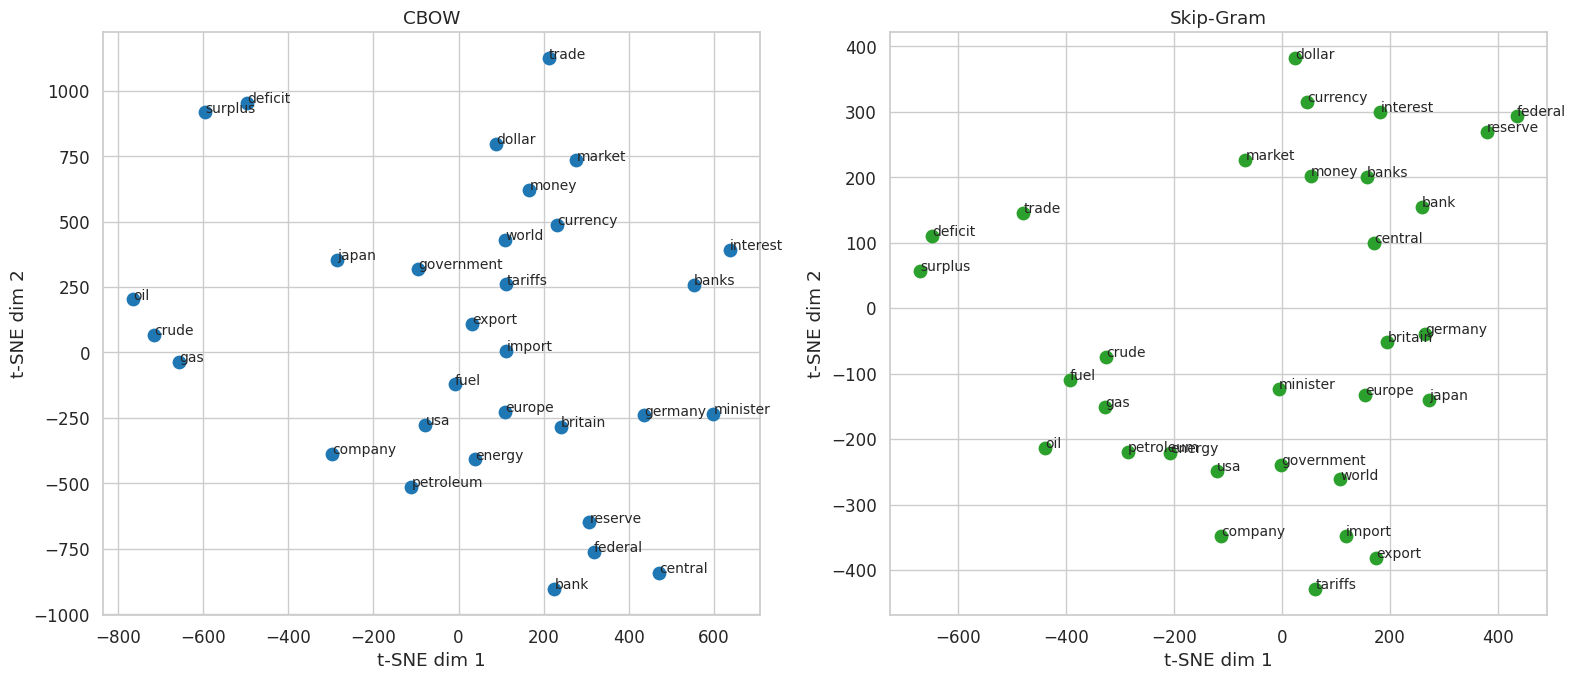

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model, title, color in [
    (axes[0], model_cbow, "CBOW", "tab:blue"),
    (axes[1], model_skip, "Skip-Gram", "tab:green")
]:

    words = [w for w in words_to_plot if w in model.wv]
    vectors = np.array([model.wv[w] for w in words])

    pca = PCA(n_components=10, random_state=42)
    vecs_pca = pca.fit_transform(vectors)

    tsne = TSNE(
        n_components=2,
        perplexity=5,
        learning_rate=200,
        max_iter=1000,
        random_state=42
    )

    vecs_2d = tsne.fit_transform(vecs_pca)

    ax.scatter(vecs_2d[:,0], vecs_2d[:,1], s=80, c=color)

    for i, w in enumerate(words):
        ax.text(vecs_2d[i,0]+0.5, vecs_2d[i,1]+0.5, w, fontsize=10)

    ax.set_title(title)
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")

plt.tight_layout()
plt.show()

In [25]:
!git clone https://github.com/bereketsimma/wordembading.git


Cloning into 'wordembading'...


In [26]:
%cd wordembading


/content/wordembading/wordembading


In [41]:
from google.colab import drive
drive.mount('/content/drive')
!find /content/drive/MyDrive -name "*.ipynb"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ViT_CIFAR10_Beginner_Friendly.ipynb
/content/drive/MyDrive/VIT_for_image_classification.ipynb
/content/drive/MyDrive/Colab Notebooks/model explaneblity.ipynb
/content/drive/MyDrive/Colab Notebooks/SHAP_House_Pricing.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/contrastive-learning task.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
/content/drive/MyDrive/Colab Notebooks/neuranlnettest.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
/content/drive/MyDrive/Colab Notebooks/continual-learning.ipynb
/content/drive/MyDrive/Colab Notebooks/qc.ipynb
/content/drive/MyDrive/Colab Notebooks/pca (1).ipynb
/content/drive/MyDrive/Colab Notebooks/pca.ipynb
/conte

In [43]:
%cd /content/wordembading/wordembading


/content/wordembading/wordembading


In [51]:
!git remote -v

origin	https://github.com/bereketsimma/wordembading.git (fetch)
origin	https://github.com/bereketsimma/wordembading.git (push)


In [54]:
!cp "/content/drive/MyDrive/Colab Notebooks/wordembading.ipynb" .
!ls

!git config --global user.name "bereketsimma"
!git config --global user.email "bekisimma@gmail.com"
!git add wordembading.ipynb
!git commit -m "Add Word2Vec Colab notebook"
!git push -u origin main

wordembading.ipynb
[main 1f2507b] Add Word2Vec Colab notebook
 1 file changed, 1 insertion(+), 1 deletion(-)
fatal: could not read Username for 'https://github.com': No such device or address


In [53]:
!ls
!git status
!git branch --unset-upstream

wordembading.ipynb
On branch main
Your branch is based on 'origin/main', but the upstream is gone.
  (use "git branch --unset-upstream" to fixup)

nothing to commit, working tree clean
